# 🛍️ AI Product Recommendation Engine

## 📌 Overview

This project implements an AI-powered Smart Product Recommendation System using **Computer Vision** and **Generative AI**.

The system analyzes a product image, understands the product using an AI vision model, detects the product category, and recommends complementary fashion products from the Fashion Product Images Dataset.

---

## ✨ Features

- 📷 Product Image Analysis
- 🤖 AI Caption Generation using BLIP
- 🏷️ Product Category Detection
- 🛒 Smart Product Recommendation
- 🖼️ Visual Recommendation using Real Product Images

---

## 📂 Dataset

**Fashion Product Images Dataset (Kaggle)**

---

## 🛠️ Technologies Used

- Python
- Pandas
- Matplotlib
- PyTorch
- Hugging Face Transformers
- BLIP Image Captioning Model
- Kaggle Notebook

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import torch

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration
)

## ⚙️ GPU Configuration

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 50)
print("Device :", device)

if device == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))

print("=" * 50)

Device : cuda
GPU : Tesla T4


## 📂 Load Fashion Product Dataset

In [3]:
DATASET = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

IMAGE_FOLDER = os.path.join(DATASET, "images")
CSV_FILE = os.path.join(DATASET, "styles.csv")

df = pd.read_csv(CSV_FILE, on_bad_lines="skip")

df = df.dropna()

print("Dataset Loaded Successfully!")
print("Total Products :", len(df))

Dataset Loaded Successfully!
Total Products : 44077


## 📊 Explore Dataset

In [4]:
print(df.head())

print("\nColumns:\n")
print(df.columns)

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

Columns:

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage',

## 🖼️ Display a Sample Product

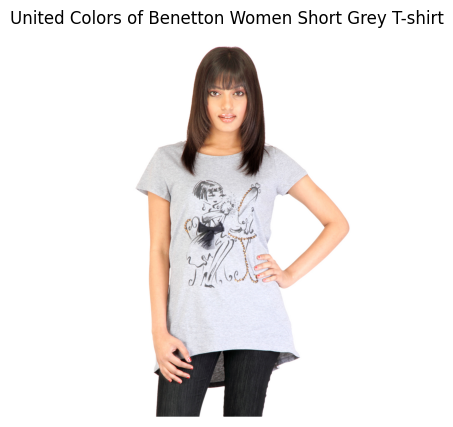

In [5]:
sample = df.sample(1).iloc[0]

image_path = os.path.join(
    IMAGE_FOLDER,
    f"{sample['id']}.jpg"
)

image = Image.open(image_path)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.title(sample["productDisplayName"])
plt.show()

## 🤖 Load BLIP Image Captioning Model

In [6]:
print("Loading BLIP model...")

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("✅ BLIP model loaded successfully!")

Loading BLIP model...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

✅ BLIP model loaded successfully!


## 📝 Generate Caption for Product Image

In [7]:
def generate_caption(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        image,
        return_tensors="pt"
    ).to(device)

    output = model.generate(**inputs)

    caption = processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return image, caption

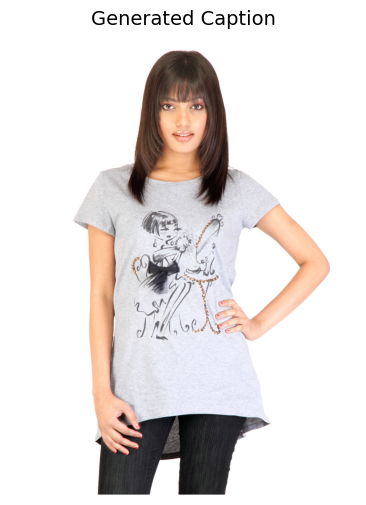

Caption:
a woman wearing a grey shirt with a black and white drawing on it


In [8]:
image, caption = generate_caption(image_path)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Caption", fontsize=14)
plt.show()

print("Caption:")
print(caption)

## 🏷️ Product Category Detection

In [9]:
def detect_category(caption):

    caption = caption.lower()

    category_keywords = {

    "Shirts": ["shirt"],

    "Tshirts": ["t-shirt", "tshirt"],

    "Jeans": ["jeans", "denim"],

    "Sports Shoes": [
    "sports shoe",
    "running shoe",
    "shoe",
    "shoes",
    "sneaker",
    "nike",
    "adidas",
    "puma"
],

    "Casual Shoes": ["casual shoe"],

    "Formal Shoes": ["formal shoe"],

    "Kurtas": ["kurta"],

    "Tunics": ["tunic"],

    "Tops": ["top"],

    "Dresses": ["dress"],

    "Sarees": ["saree"],

    "Sweaters": ["sweater"],

    "Jackets": ["jacket"],

    "Sweatshirts": ["sweatshirt", "hoodie"],

    "Handbags": ["handbag", "bag"],

    "Belts": ["belt"],

    "Watches": ["watch"]
}

    for category, keywords in category_keywords.items():
        for keyword in keywords:
            if keyword in caption:
                return category

    return "Unknown"

In [10]:
category = detect_category(caption)

print("Generated Caption :", caption)
print("Detected Category :", category)

Generated Caption : a woman wearing a grey shirt with a black and white drawing on it
Detected Category : Shirts


## 🎯 Recommendation Knowledge Base

In [11]:
recommendation_map = {

    # ----------- Men's Clothing -----------

    "Shirts": ["Jeans", "Belts", "Watches", "Casual Shoes"],

    "Tshirts": ["Jeans", "Sports Shoes", "Caps", "Watches"],

    "Jeans": ["Shirts", "Belts", "Casual Shoes", "Watches"],

    "Trousers": ["Formal Shoes", "Belts", "Shirts", "Watches"],

    "Shorts": ["Tshirts", "Sports Shoes", "Caps"],

    "Track Pants": ["Sports Shoes", "Tshirts", "Caps"],

    "Blazers": ["Formal Shoes", "Shirts", "Watches"],

    "Waistcoat": ["Formal Shoes", "Shirts", "Trousers"],



    # ----------- Women's Clothing -----------

    "Kurtas": ["Leggings", "Dupatta", "Sandals", "Handbags"],

    "Kurta Sets": ["Sandals", "Handbags", "Earrings"],

    "Tops": ["Jeans", "Handbags", "Flats"],

    "Tunics": ["Leggings", "Handbags", "Flats"],

    "Dresses": ["Heels", "Handbags", "Necklace and Chains"],

    "Skirts": ["Tops", "Flats", "Handbags"],

    "Sarees": ["Jewellery Set", "Heels", "Clutches"],

    "Lehenga Choli": ["Jewellery Set", "Heels", "Clutches"],



    # ----------- Shoes -----------

    "Sports Shoes": ["Track Pants", "Tshirts", "Caps"],

    "Casual Shoes": ["Jeans", "Shirts", "Belts"],

    "Formal Shoes": ["Trousers", "Blazers", "Belts"],

    "Sandals": ["Kurtas", "Handbags", "Earrings"],

    "Heels": ["Dresses", "Handbags", "Necklace and Chains"],

    "Flats": ["Tops", "Jeans", "Handbags"],



    # ----------- Accessories -----------

    "Belts": ["Jeans", "Shirts", "Casual Shoes"],

    "Wallets": ["Belts", "Casual Shoes", "Watches"],

    "Handbags": ["Dresses", "Heels", "Necklace and Chains"],

    "Backpacks": ["Tshirts", "Jeans", "Sports Shoes"],

    "Caps": ["Sports Shoes", "Track Pants", "Tshirts"],

    "Watches": ["Shirts", "Jeans", "Belts"],

    "Sunglasses": ["Tshirts", "Jeans", "Caps"],



    # ----------- Jewellery -----------

    "Ring": ["Bracelet", "Necklace and Chains", "Earrings"],

    "Bracelet": ["Ring", "Watch", "Necklace and Chains"],

    "Pendant": ["Earrings", "Bracelet", "Ring"],

    "Necklace and Chains": ["Earrings", "Bracelet", "Ring"],

    "Jewellery Set": ["Sarees", "Lehenga Choli", "Heels"],

    "Earrings": ["Necklace and Chains", "Bracelet", "Ring"],



    # ----------- Beauty -----------

    "Lipstick": ["Kajal and Eyeliner", "Foundation and Primer"],

    "Perfume and Body Mist": ["Deodorant", "Body Lotion"],

    "Face Wash and Cleanser": ["Face Moisturisers", "Body Lotion"],

    "Foundation and Primer": ["Lipstick", "Kajal and Eyeliner"],



    # ----------- Bags -----------

    "Laptop Bag": ["Wallets", "Belts"],

    "Messenger Bag": ["Wallets", "Belts"],

    "Duffel Bag": ["Sports Shoes", "Track Pants"],

    "Clutches": ["Sarees", "Heels", "Jewellery Set"]

}

## 🖼️ Display Recommended Products

In [12]:
def display_products(products):

    if products.empty:
        print("No products found.")
        return

    plt.figure(figsize=(14,5))

    for i, (_, row) in enumerate(products.iterrows()):

        image_path = os.path.join(
            IMAGE_FOLDER,
            f"{row['id']}.jpg"
        )

        if not os.path.exists(image_path):
            continue

        image = Image.open(image_path)

        plt.subplot(1, len(products), i+1)
        plt.imshow(image)
        plt.axis("off")

        plt.title(
    f"{row['productDisplayName']}\n"
    f"{row['baseColour']} | {row['season']}",
    fontsize=8
)

    plt.tight_layout()
    plt.show()

## 🔍 Search Recommended Products from Dataset

In [13]:
def search_products(article_type, top_n=2):

    # Remove rows with missing articleType
    products = df[df["articleType"].notna()].copy()

    # Case-insensitive matching
    products = products[
        products["articleType"].str.strip().str.lower() ==
        article_type.strip().lower()
    ]

    valid_products = []

    for _, row in products.iterrows():

        image_path = os.path.join(
            IMAGE_FOLDER,
            f"{row['id']}.jpg"
        )

        if os.path.exists(image_path):
            valid_products.append(row)

        if len(valid_products) >= top_n:
            break

    return pd.DataFrame(valid_products)


Recommended Fashion Pairings


👕 Recommended Category : Jeans


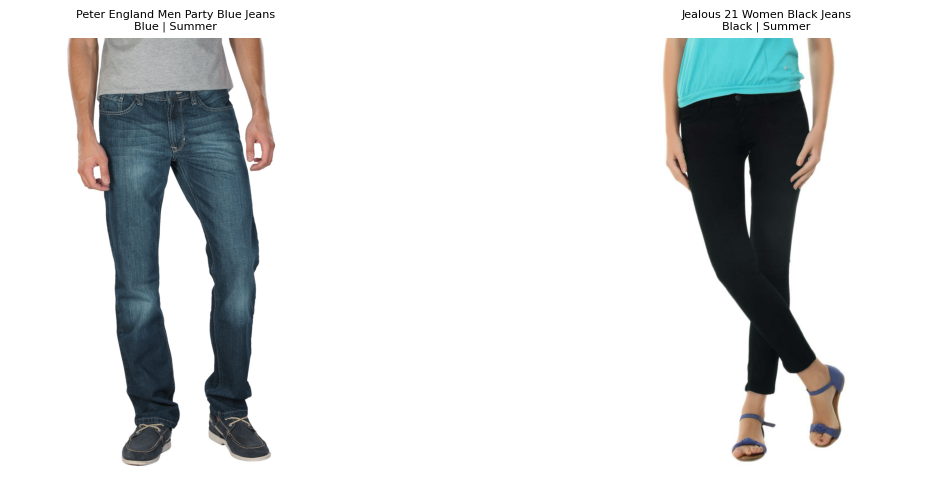


👕 Recommended Category : Belts


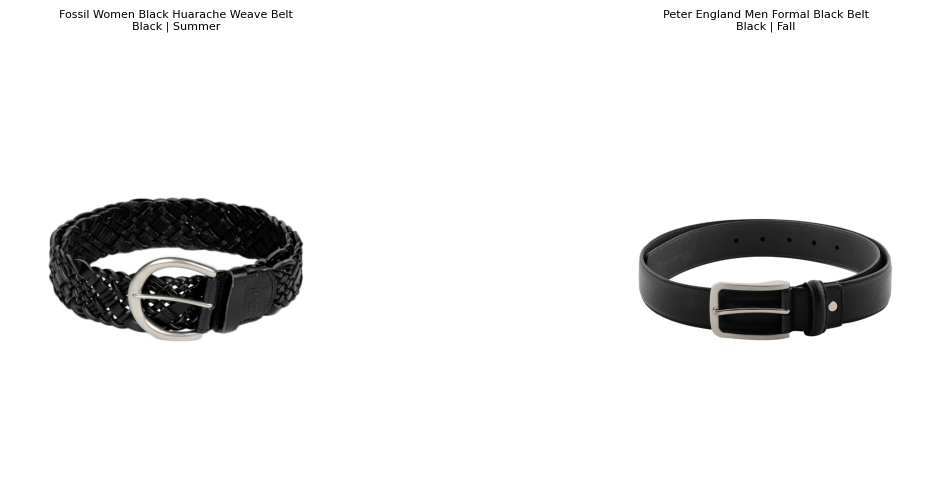


👕 Recommended Category : Watches


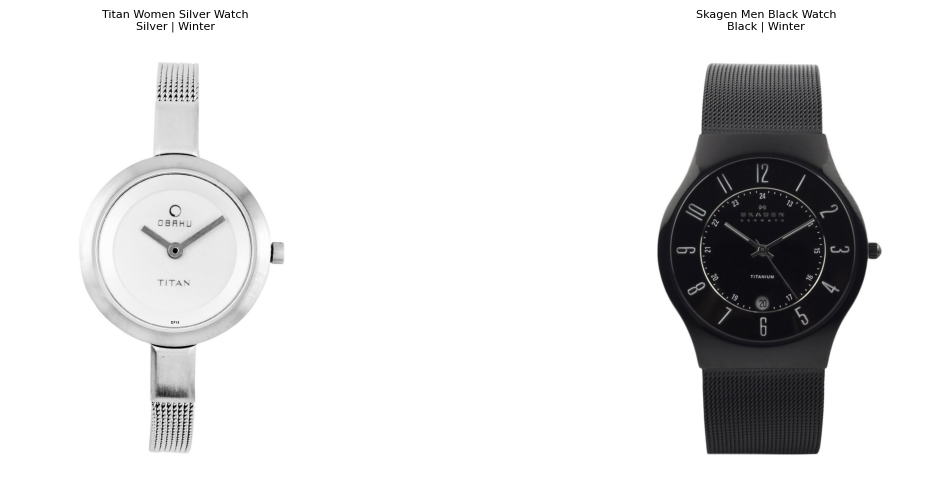


👕 Recommended Category : Casual Shoes


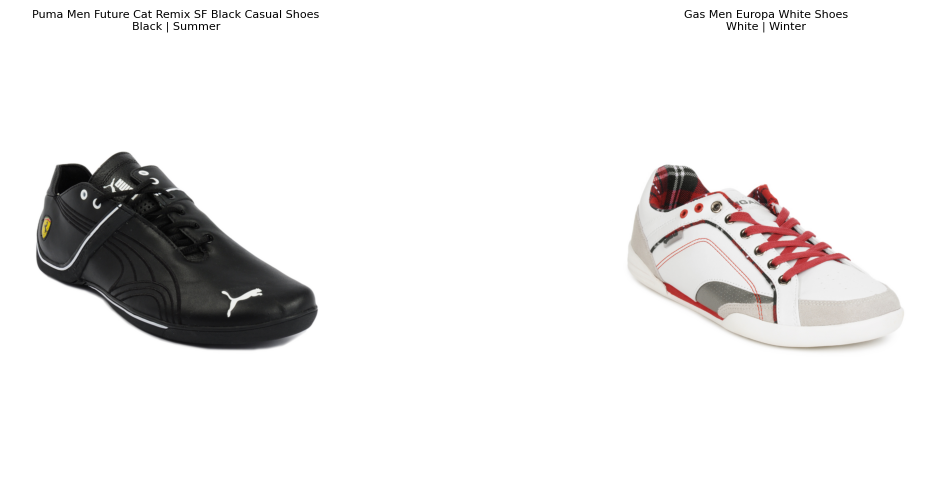

In [14]:
if category in recommendation_map:

    print("\nRecommended Fashion Pairings\n")

    for item in recommendation_map[category]:

        print("\n" + "=" * 60)
        print(f"👕 Recommended Category : {item}")
        print("=" * 60)

        products = search_products(item, top_n=2)

        if len(products) == 0:
            print("No products found in dataset.")
        else:
            display_products(products)

else:

    print("\nNo predefined outfit recommendations available.")

    print("\nShowing similar products from dataset...\n")

    products = search_products(category, top_n=5)

    if len(products) == 0:
        print("No similar products found.")
    else:
        display_products(products)

In [15]:
recommendation_reason = {
    "Jeans": "Jeans pair well with shirts and tops.",
    "Leggings": "Leggings are commonly paired with tunics and kurtas.",
    "Casual Shoes": "Casual shoes complete everyday outfits.",
    "Sports Shoes": "Sports shoes provide comfort for active wear.",
    "Watches": "A watch enhances the overall fashion look.",
    "Belts": "Belts improve the outfit's style.",
    "Handbags": "Handbags complement women's outfits.",
    "Sandals": "Sandals are comfortable and stylish.",
    "Wallets": "Wallets are useful fashion accessories.",
    "Shirts": "Shirts match well with jeans and trousers.",
    "Tops": "Tops are suitable with jeans and leggings."
}

In [16]:
recommendation_reason["Jeans"] = "Jeans pair well with sports shoes."
recommendation_reason["Tshirts"] = "T-shirts complement sports shoes for a casual look."
recommendation_reason["Watches"] = "A watch completes a sporty outfit."

## ✅ Test Product Search

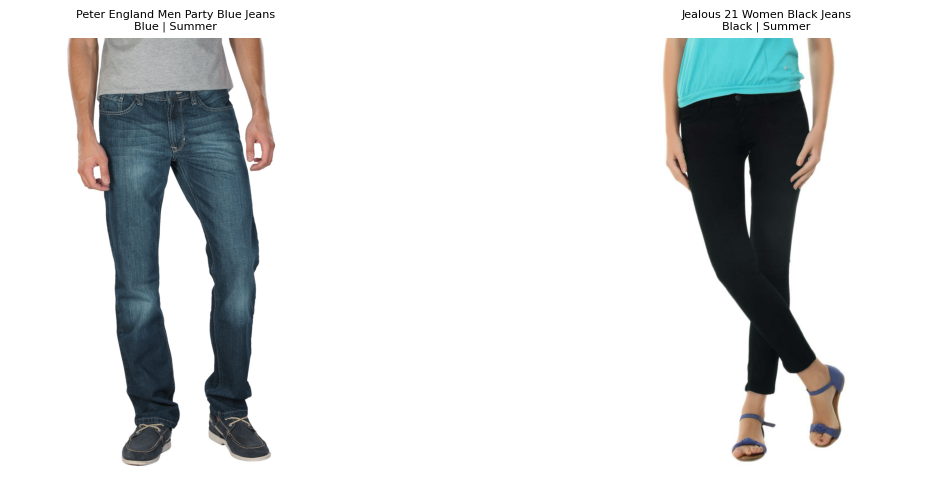

In [17]:
products = search_products("Jeans")

display_products(products)

## 🤖 AI Product Recommendation Pipeline

In [18]:
def detect_category(caption):

    caption = caption.lower().strip()

    # ----------------------------
    # Manual keyword mapping
    # ----------------------------

    keyword_map = {

        "Shirts": [
            "shirt", "formal shirt", "casual shirt"
        ],

        "Tshirts": [
            "tshirt", "t-shirt", "tee"
        ],

        "Jeans": [
            "jeans", "denim"
        ],

        "Trousers": [
            "trouser", "trousers", "pants"
        ],

        "Shorts": [
            "shorts"
        ],

        "Track Pants": [
            "track pant", "track pants", "jogger", "joggers"
        ],

        "Kurtas": [
            "kurta", "kurti"
        ],

        "Kurta Sets": [
            "kurta set"
        ],

        "Tunics": [
            "tunic"
        ],

        "Tops": [
            "top"
        ],

        "Dresses": [
            "dress", "gown"
        ],

        "Skirts": [
            "skirt"
        ],

        "Sarees": [
            "saree"
        ],

        "Lehenga Choli": [
            "lehenga"
        ],

        "Sports Shoes": [
            "sports shoe",
            "running shoe",
            "running shoes",
            "sneaker",
            "sneakers",
            "nike",
            "adidas",
            "puma",
            "reebok",
            "shoe",
            "shoes"
        ],

        "Casual Shoes": [
            "casual shoe",
            "loafer"
        ],

        "Formal Shoes": [
            "formal shoe"
        ],

        "Sandals": [
            "sandal",
            "sandals"
        ],

        "Heels": [
            "heel",
            "heels"
        ],

        "Flats": [
            "flat",
            "flats"
        ],

        "Belts": [
            "belt"
        ],

        "Wallets": [
            "wallet"
        ],

        "Handbags": [
            "handbag",
            "bag",
            "purse",
            "tote"
        ],

        "Backpacks": [
            "backpack"
        ],

        "Messenger Bag": [
            "messenger bag"
        ],

        "Laptop Bag": [
            "laptop bag"
        ],

        "Duffel Bag": [
            "duffel bag"
        ],

        "Clutches": [
            "clutch"
        ],

        "Caps": [
            "cap"
        ],

        "Watches": [
            "watch",
            "wristwatch"
        ],

        "Sunglasses": [
            "sunglasses",
            "glasses"
        ],

        "Ring": [
            "ring"
        ],

        "Bracelet": [
            "bracelet",
            "bangle"
        ],

        "Pendant": [
            "pendant"
        ],

        "Necklace and Chains": [
            "necklace",
            "chain"
        ],

        "Jewellery Set": [
            "jewellery set",
            "jewelry set"
        ],

        "Earrings": [
            "earring",
            "earrings"
        ],

        "Lipstick": [
            "lipstick"
        ],

        "Perfume and Body Mist": [
            "perfume",
            "body mist"
        ],

        "Face Wash and Cleanser": [
            "face wash",
            "cleanser"
        ],

        "Foundation and Primer": [
            "foundation",
            "primer"
        ]

    }

    # ----------------------------
    # First check keyword map
    # ----------------------------

    for category, keywords in keyword_map.items():

        for keyword in keywords:

            if keyword in caption:
                return category

    # ----------------------------
    # Then check dataset article types
    # ----------------------------

    article_types = sorted(
        df["articleType"].dropna().unique(),
        key=len,
        reverse=True
    )

    for article in article_types:

        if article.lower() in caption:
            return article

    return "Unknown"

In [19]:
recommendation_map["Handbags"] = [
    "Watches",
    "Wallets",
    "Casual Shoes"
]

In [20]:
recommendation_map["Watches"] = [
    "Shirts",
    "Jeans",
    "Casual Shoes"
]

In [21]:
recommendation_map["Sports Shoes"] = [
    "Jeans",
    "Tshirts",
    "Watches"
]

## 🚀 Final Output

In [22]:
# Run the recommendation pipeline
category = detect_category(caption).strip()

print(f"Generated Caption : {caption}")
print(f"Detected Category : {category}")

if category in recommendation_map:
    print("\nRecommended Fashion Pairings\n")
    for item in recommendation_map[category]:
        print("\n" + "="*60)
        print(f"👕 Recommended Category : {item}")
        print("="*60)
        products = search_products(item, top_n=2)
        if len(products)==0:
            print("No products found in dataset.")
        else:
            display_products(products)
else:
    print("No recommendations available.")

NameError: name 'smart_recommend' is not defined

In [ ]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("Total Products :", len(df))
print("Total Categories :", df["articleType"].nunique())
print("Unique Master Categories :", df["masterCategory"].nunique())
print("Unique Sub Categories :", df["subCategory"].nunique())

# 🏗️ AI Fashion Recommendation Pipeline

```text
┌─────────────────────┐
│   Product Image     │
└─────────┬───────────┘
          │
          ▼
┌─────────────────────┐
│ BLIP Caption Model  │
└─────────┬───────────┘
          │
          ▼
┌─────────────────────┐
│ Category Detection  │
└─────────┬───────────┘
          │
          ▼
┌─────────────────────┐
│ Recommendation KB   │
└─────────┬───────────┘
          │
          ▼
┌─────────────────────┐
│ Dataset Search      │
└─────────┬───────────┘
          │
          ▼
┌─────────────────────┐
│ Recommended Items   │
└─────────────────────┘
```

# 🎯 Project Summary

## Objective
Develop an AI-powered fashion recommendation system capable of analyzing product images and recommending complementary products.

## AI Workflow

1. Product Image Input
2. BLIP Caption Generation
3. Product Category Detection
4. Recommendation Engine
5. Fashion Dataset Search
6. Visual Product Recommendations

## Technologies Used

- Python
- PyTorch
- Hugging Face Transformers
- BLIP
- Pandas
- Matplotlib
- Kaggle Notebook

## Outcome

The system successfully understands a fashion product image and recommends complementary fashion items using AI-generated image captions and a curated recommendation knowledge base.